# FinMark Corporation - Data Cleaning & EDA

## 📌 Project Overview
FinMark Corporation is a financial services company that wants to strengthen its ability to generate insights from customer data. As the data analyst, your role is to build the foundation for a **machine learning solution** by first ensuring data quality and conducting exploratory data analysis (EDA).

This notebook focuses on **Milestone 1** of the project: cleaning the data and performing an initial EDA. The work here will prepare the datasets for visualization and model development in later stages.


### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use("ggplot")
sns.set_palette("Set2")

In [3]:
demographics = pd.read_csv("CLEANED_customer_demographics.csv")
transactions = pd.read_csv("CLEANED_customer_transactions.csv")
social = pd.read_csv("clean_social_media_interactions.csv")

In [4]:
demographics

,CustomerID,Age,Gender,Location,IncomeLevel,SignupDate
0,9207fa75-5758-48d1-94ad-19c041e0520f,51.0,Female,Jensenberg,Low,2022-11-17
1,5fb09cd8-a473-46f7-80bd-6e49cf509078,NaN,Female,Castilloport,High,2020-07-21
2,c139496e-cc89-498a-bd90-1fb4627b6cff,37.0,Male,Lake Jennifertown,NaN,2021-01-01
3,50118139-7264-428f-81cc-a25fddc5d6dd,44.0,Male,Port Carl,Medium,2024-06-10
4,7d1f2bbc-8d16-4fbc-9b37-ece3324e8ed4,50.0,Female,Jessebury,High,2023-08-24
...,...,...,...,...,...,...
3018,48313b18-ccdb-4946-b958-1ebfc92dcc2a,59.0,Male,South Andrea,High,2020-02-26
3019,bbe76a26-234f-4a70-b71f-fa9b183f6353,Unknown,Male,Gregoryfurt,High,2020-06-23
3020,7eb7f7df-9b0a-416a-829e-bcf4d8bd57dc,55.0,Male,New Anthonyland,High,2022-07-23
3021,ce5cf079-859b-43fa-9609-c6bb7e12c6b7,41.0,Female,Adrianhaven,Low,2024-01-10


In [5]:
transactions

,CustomerID,TransactionID,TransactionDate,Amount,ProductCategory,PaymentMethod
0,60567026-f719-4cd6-849e-137e86d8938f,5ff75116-0a50-4d04-80fb-31e5ccbb0769,2024-05-15,117.64,Clothing,PayPal
1,4090ba85-b111-4f75-a792-c777965f5255,2c39b9fe-ff57-4d39-9321-9f5cdf187aa1,2023-04-26,466.14,Health & Beauty,Bank Transfer
2,9223891b-73ff-4d5c-b8ae-13ece82ee28b,f79588dd-3db9-4ffa-97f8-7de0e64259f1,2022-09-23,563.99,Clothing,Debit Card
3,9243eebc-938f-480c-8564-16d503d250de,401c0fc9-60df-4455-ad78-67c132f9897d,2024-04-15,254.44,Automotive,PayPal
4,6e3e8eb8-bc0f-4ffe-9f74-5d5efec9502f,2034aebc-8280-4254-a667-92bcd1c2be4f,2024-06-03,590.52,Home & Garden,Bank Transfer
...,...,...,...,...,...,...
3010,086370e7-8884-47d7-89b0-776401a43e1c,652636b6-5c72-44e1-aefb-6adce412ee75,2023-12-05,974.25,Electronics,Debit Card
3011,7c7df909-aa25-48c7-af9d-6ebe714b28b6,eb26a4f4-5af2-4e25-b1f2-fd0de5583f7b,10/08/2022,50.07,Automotive,Bank Transfer
3012,79fc606a-c02c-4c39-b065-3e88a59b366c,7fbe5cc4-a35e-4e8e-89d7-7b439659b9f6,20/07/2022,272.68,Clothing,Debit Card
3013,6a84f1a7-f636-4300-bd8d-c7f888460829,185ee140-348a-4461-bd40-07a7e8535815,2023-10-09,0,Health & Beauty,PayPal


In [6]:
social

,CustomerID,InteractionID,InteractionDate,Platform,InteractionType,Sentiment
0,2dcb9523-356b-40b2-a67b-1f27797de261,e5d15761-d0a7-4329-89e3-79a892c56097,2023-07-11,NaN,Comment,NaN
1,e12c37b3-7d4d-472f-9fd8-0df2cb3001aa,02f9f376-70ae-4fcd-9070-1db977939948,2023-07-06,Twitter,Share,NaN
2,08a911a3-65e6-4f5d-a6a1-ae7ddcbe28a2,a83fa04c-f109-4f24-8ce1-2078154f6a1c,2024-05-24,Instagram,Comment,Neutral
3,efdfdfc9-5dbb-4478-911a-101a390a0285,28a69c4b-a2e4-4c74-a130-1132d7733fdf,2023-11-01,Instagram,Like,Neutral
4,ca1e90f6-0e5f-492e-ab92-252ff540da18,d9d1c6f8-5e15-4738-b52b-13c2982420cc,2023-07-08,Instagram,Like,NaN
...,...,...,...,...,...,...
3015,e06f0e16-8e48-483b-b103-9f105b139ca8,071a2657-12a8-4216-9c64-baf9ab5c9420,2024-04-30,Twitter,Share,Neutral
3016,4d20c2b1-2f8a-4066-902c-bd068c2adccc,e5be1d7a-fdba-4e91-8674-577ac01cddf0,2024-05-16,NaN,Like,Very Negative
3017,b7b84b81-c61b-4f23-b3db-b18010484122,93d2d3e1-841e-4ece-91c1-3b1998a4cab8,2023-12-16,Twitter,Like,Neutral
3018,5659a8c6-0397-4396-b561-52ec1c8a760b,d7f6806b-f348-431e-9198-07f0685d8d8e,2024-01-28,Facebook,Share,Negative


## Data Cleaning

In [7]:
print("Null values per dataset:")
print("Demographics:\n", demographics.isnull().sum())
print("Transactions:\n", transactions.isnull().sum())
print("Social Media:\n", social.isnull().sum())

Null values per dataset:
Demographics:
 CustomerID       0
Age            276
Gender           0
Location         0
IncomeLevel    285
SignupDate       0
dtype: int64
Transactions:
 CustomerID           0
TransactionID        0
TransactionDate      0
Amount             283
ProductCategory    282
PaymentMethod        0
dtype: int64
Social Media:
 CustomerID           0
InteractionID        0
InteractionDate      0
Platform           291
InteractionType      0
Sentiment          309
dtype: int64


In [9]:
# Convert Age to numeric before imputation
demographics["Age"] = pd.to_numeric(demographics["Age"], errors="coerce")
demographics["Age"] = demographics["Age"].fillna(demographics["Age"].median())

In [11]:
# Convert Amount to numeric, coerce errors if any
transactions["Amount"] = pd.to_numeric(transactions["Amount"], errors="coerce")
transactions["Amount"] = transactions["Amount"].fillna(transactions["Amount"].median())

In [12]:
# Fill missing values in demographics
demographics["Age"] = demographics["Age"].fillna(demographics["Age"].median())
demographics["IncomeLevel"] = demographics["IncomeLevel"].fillna("Unknown")

# Fill missing values in transactions
transactions["Amount"] = transactions["Amount"].fillna(transactions["Amount"].median())
transactions["ProductCategory"] = transactions["ProductCategory"].fillna("Unknown")

# Fill missing values in social media
social["Platform"] = social["Platform"].fillna("Unknown")
social["Sentiment"] = social["Sentiment"].fillna("Unknown")

# Double-check if nulls remain
print("Remaining nulls after imputation:")
print("Demographics:\n", demographics.isnull().sum())
print("Transactions:\n", transactions.isnull().sum())
print("Social Media:\n", social.isnull().sum())

Remaining nulls after imputation:
Demographics:
 CustomerID     0
Age            0
Gender         0
Location       0
IncomeLevel    0
SignupDate     0
dtype: int64
Transactions:
 CustomerID         0
TransactionID      0
TransactionDate    0
Amount             0
ProductCategory    0
PaymentMethod      0
dtype: int64
Social Media:
 CustomerID         0
InteractionID      0
InteractionDate    0
Platform           0
InteractionType    0
Sentiment          0
dtype: int64


#### Save the cleaned file

In [13]:
demographics.to_csv("CLEANED_customer_demographics_v2.csv", index=False)
transactions.to_csv("CLEANED_customer_transactions_v2.csv", index=False)
social.to_csv("clean_social_media_interactions_v2.csv", index=False)

print("Cleaned datasets saved as *_v2.csv")

Cleaned datasets saved as *_v2.csv


In [15]:
demographics_v2 = pd.read_csv("/content/CLEANED_customer_demographics_v2.csv")
transactions_v2 = pd.read_csv("/content/CLEANED_customer_transactions_v2.csv")
social_v2 = pd.read_csv("/content/clean_social_media_interactions_v2.csv")

In [16]:
demographics_v2

,CustomerID,Age,Gender,Location,IncomeLevel,SignupDate
0,9207fa75-5758-48d1-94ad-19c041e0520f,51.0,Female,Jensenberg,Low,2022-11-17
1,5fb09cd8-a473-46f7-80bd-6e49cf509078,45.0,Female,Castilloport,High,2020-07-21
2,c139496e-cc89-498a-bd90-1fb4627b6cff,37.0,Male,Lake Jennifertown,Unknown,2021-01-01
3,50118139-7264-428f-81cc-a25fddc5d6dd,44.0,Male,Port Carl,Medium,2024-06-10
4,7d1f2bbc-8d16-4fbc-9b37-ece3324e8ed4,50.0,Female,Jessebury,High,2023-08-24
...,...,...,...,...,...,...
3018,48313b18-ccdb-4946-b958-1ebfc92dcc2a,59.0,Male,South Andrea,High,2020-02-26
3019,bbe76a26-234f-4a70-b71f-fa9b183f6353,45.0,Male,Gregoryfurt,High,2020-06-23
3020,7eb7f7df-9b0a-416a-829e-bcf4d8bd57dc,55.0,Male,New Anthonyland,High,2022-07-23
3021,ce5cf079-859b-43fa-9609-c6bb7e12c6b7,41.0,Female,Adrianhaven,Low,2024-01-10


In [17]:
transactions_v2

,CustomerID,TransactionID,TransactionDate,Amount,ProductCategory,PaymentMethod
0,60567026-f719-4cd6-849e-137e86d8938f,5ff75116-0a50-4d04-80fb-31e5ccbb0769,2024-05-15,117.64,Clothing,PayPal
1,4090ba85-b111-4f75-a792-c777965f5255,2c39b9fe-ff57-4d39-9321-9f5cdf187aa1,2023-04-26,466.14,Health & Beauty,Bank Transfer
2,9223891b-73ff-4d5c-b8ae-13ece82ee28b,f79588dd-3db9-4ffa-97f8-7de0e64259f1,2022-09-23,563.99,Clothing,Debit Card
3,9243eebc-938f-480c-8564-16d503d250de,401c0fc9-60df-4455-ad78-67c132f9897d,2024-04-15,254.44,Automotive,PayPal
4,6e3e8eb8-bc0f-4ffe-9f74-5d5efec9502f,2034aebc-8280-4254-a667-92bcd1c2be4f,2024-06-03,590.52,Home & Garden,Bank Transfer
...,...,...,...,...,...,...
3010,086370e7-8884-47d7-89b0-776401a43e1c,652636b6-5c72-44e1-aefb-6adce412ee75,2023-12-05,974.25,Electronics,Debit Card
3011,7c7df909-aa25-48c7-af9d-6ebe714b28b6,eb26a4f4-5af2-4e25-b1f2-fd0de5583f7b,10/08/2022,50.07,Automotive,Bank Transfer
3012,79fc606a-c02c-4c39-b065-3e88a59b366c,7fbe5cc4-a35e-4e8e-89d7-7b439659b9f6,20/07/2022,272.68,Clothing,Debit Card
3013,6a84f1a7-f636-4300-bd8d-c7f888460829,185ee140-348a-4461-bd40-07a7e8535815,2023-10-09,0.00,Health & Beauty,PayPal


In [18]:
social_v2

,CustomerID,InteractionID,InteractionDate,Platform,InteractionType,Sentiment
0,2dcb9523-356b-40b2-a67b-1f27797de261,e5d15761-d0a7-4329-89e3-79a892c56097,2023-07-11,Unknown,Comment,Unknown
1,e12c37b3-7d4d-472f-9fd8-0df2cb3001aa,02f9f376-70ae-4fcd-9070-1db977939948,2023-07-06,Twitter,Share,Unknown
2,08a911a3-65e6-4f5d-a6a1-ae7ddcbe28a2,a83fa04c-f109-4f24-8ce1-2078154f6a1c,2024-05-24,Instagram,Comment,Neutral
3,efdfdfc9-5dbb-4478-911a-101a390a0285,28a69c4b-a2e4-4c74-a130-1132d7733fdf,2023-11-01,Instagram,Like,Neutral
4,ca1e90f6-0e5f-492e-ab92-252ff540da18,d9d1c6f8-5e15-4738-b52b-13c2982420cc,2023-07-08,Instagram,Like,Unknown
...,...,...,...,...,...,...
3015,e06f0e16-8e48-483b-b103-9f105b139ca8,071a2657-12a8-4216-9c64-baf9ab5c9420,2024-04-30,Twitter,Share,Neutral
3016,4d20c2b1-2f8a-4066-902c-bd068c2adccc,e5be1d7a-fdba-4e91-8674-577ac01cddf0,2024-05-16,Unknown,Like,Very Negative
3017,b7b84b81-c61b-4f23-b3db-b18010484122,93d2d3e1-841e-4ece-91c1-3b1998a4cab8,2023-12-16,Twitter,Like,Neutral
3018,5659a8c6-0397-4396-b561-52ec1c8a760b,d7f6806b-f348-431e-9198-07f0685d8d8e,2024-01-28,Facebook,Share,Negative


##  🔎 Exploratory Data Analysis (EDA)

## Objective
The goal of this EDA is to explore customer demographics, transactions, and social media interactions to identify patterns, trends, and anomalies. This step provides insights into customer behavior and prepares the data for visualization and modeling.



In [20]:
demographics_v2 = pd.read_csv("/content/CLEANED_customer_demographics_v2.csv")
transactions_v2 = pd.read_csv("/content/CLEANED_customer_transactions_v2.csv")
social_v2 = pd.read_csv("/content/clean_social_media_interactions_v2.csv")

In [21]:
print("Demographics shape:", demographics_v2.shape)
print("Transactions shape:", transactions_v2.shape)
print("Social Media shape:", social_v2.shape)

Demographics shape: (3023, 6)
Transactions shape: (3015, 6)
Social Media shape: (3020, 6)


In [23]:
# Remove invalid ages
demographics_v2.loc[(demographics_v2["Age"] < 0) | (demographics_v2["Age"] > 120), "Age"] = np.nan
demographics_v2["Age"] = demographics_v2["Age"].fillna(demographics_v2["Age"].median())

# Drop duplicates by CustomerID
demographics_v2 = demographics_v2.drop_duplicates(subset=["CustomerID"], keep="first")

In [24]:
display(demographics_v2.describe(include="all"))


,CustomerID,Age,Gender,Location,IncomeLevel,SignupDate
count,3000,3000.000000,3000,3000,3000,3000
unique,3000,NaN,2,2696,4,1539
top,db9c2206-4487-47e9-8fb0-0ddc81b7310c,NaN,Female,Port Michael,High,2024-06-08
freq,1,NaN,1515,5,935,9
mean,NaN,44.679667,NaN,NaN,NaN,NaN
std,NaN,14.437054,NaN,NaN,NaN,NaN
min,NaN,18.000000,NaN,NaN,NaN,NaN
25%,NaN,34.000000,NaN,NaN,NaN,NaN
50%,NaN,45.000000,NaN,NaN,NaN,NaN
75%,NaN,57.000000,NaN,NaN,NaN,NaN


In [25]:
print("Missing Ages:", demographics_v2["Age"].isnull().sum())

Missing Ages: 0


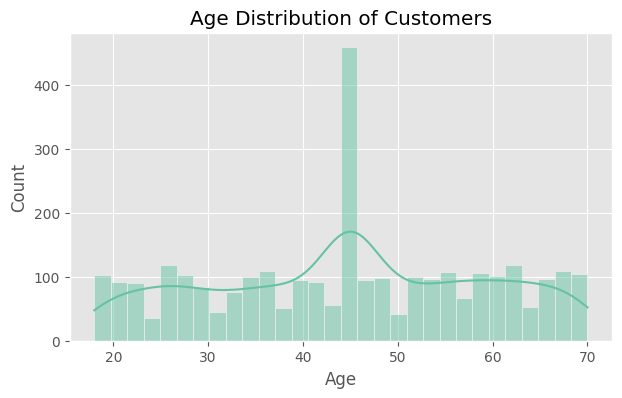

In [26]:
# Age distribution
plt.figure(figsize=(7,4))
sns.histplot(demographics_v2["Age"], bins=30, kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age"); plt.ylabel("Count")
plt.show()

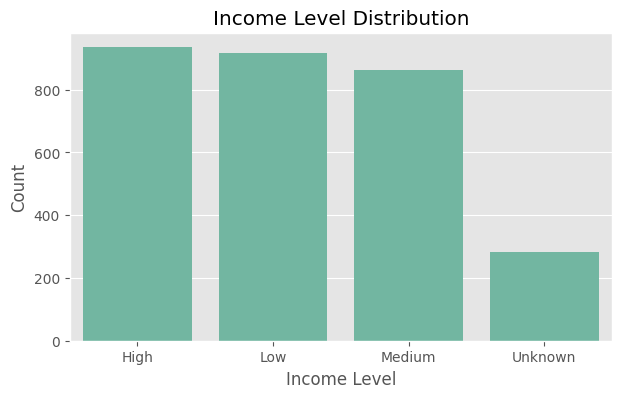

In [27]:
# Income level distribution
plt.figure(figsize=(7,4))
order_inc = demographics_v2["IncomeLevel"].value_counts().index
sns.countplot(data=demographics_v2, x="IncomeLevel", order=order_inc)
plt.title("Income Level Distribution")
plt.xlabel("Income Level"); plt.ylabel("Count")
plt.show()


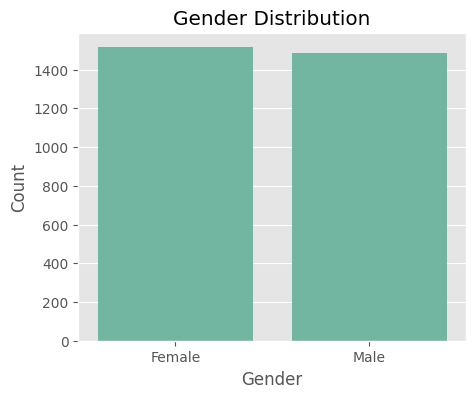

In [28]:
# Gender balance
plt.figure(figsize=(5,4))
sns.countplot(data=demographics_v2, x="Gender")
plt.title("Gender Distribution")
plt.xlabel("Gender"); plt.ylabel("Count")
plt.show()

### Customer Demographics

The majority of customers are aged between 34–57, with a median of 45, indicating a mature user base.

Gender distribution is nearly balanced, with females slightly more represented.

Income levels are skewed toward the High group, suggesting FinMark attracts a relatively affluent customer base.

# Transactions EDA


In [29]:
transactions_v2["Amount"] = pd.to_numeric(transactions_v2["Amount"], errors="coerce")

# Summary
display(transactions_v2.describe(include="all"))

,CustomerID,TransactionID,TransactionDate,Amount,ProductCategory,PaymentMethod
count,3015,3015,3015,3015.000000,3015,3015
unique,1871,3000,808,NaN,6,4
top,e54d1219-b6b3-4b5c-8b75-62f4148c23b6,f39c8b1d-595a-4656-8108-25981bf3fa14,2022-10-31,NaN,Clothing,Debit Card
freq,6,2,11,NaN,571,767
mean,NaN,NaN,NaN,490.498602,NaN,NaN
std,NaN,NaN,NaN,283.283506,NaN,NaN
min,NaN,NaN,NaN,-100.000000,NaN,NaN
25%,NaN,NaN,NaN,254.540000,NaN,NaN
50%,NaN,NaN,NaN,496.625000,NaN,NaN
75%,NaN,NaN,NaN,720.395000,NaN,NaN


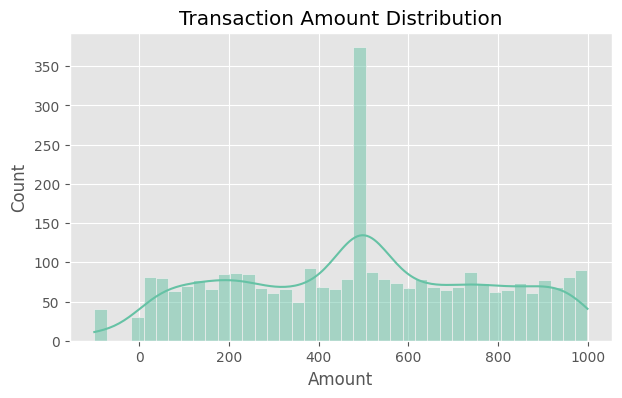

In [30]:
# Amount distribution
plt.figure(figsize=(7,4))
sns.histplot(transactions_v2["Amount"], bins=40, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount"); plt.ylabel("Count")
plt.show()

In [31]:
# Spending by Product Category
cat_sum = transactions_v2.groupby("ProductCategory")["Amount"].sum().sort_values(ascending=False)


/tmp/ipython-input-509330616.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=cat_sum.index, y=cat_sum.values, ci=None)


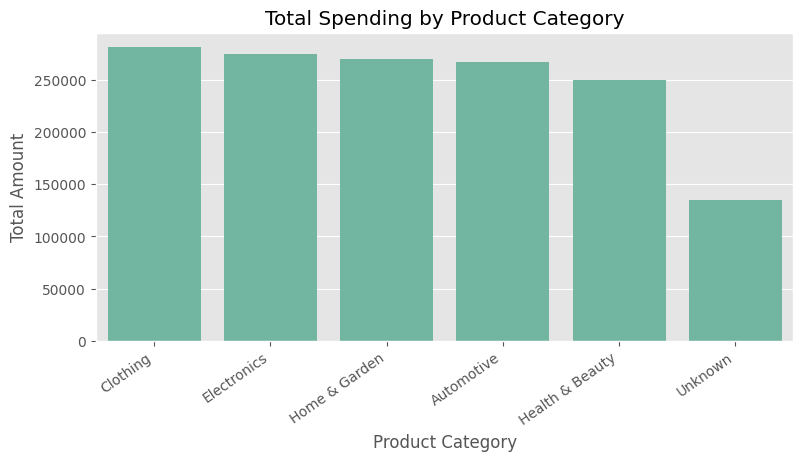

In [32]:
plt.figure(figsize=(9,4))
sns.barplot(x=cat_sum.index, y=cat_sum.values, ci=None)
plt.title("Total Spending by Product Category")
plt.xlabel("Product Category"); plt.ylabel("Total Amount")
plt.xticks(rotation=35, ha='right')
plt.show()

In [33]:
# Spending trend over time
transactions_v2["TransactionDate"] = pd.to_datetime(transactions_v2["TransactionDate"], errors="coerce")
ts = transactions_v2.dropna(subset=["TransactionDate"]).copy()
ts["Month"] = ts["TransactionDate"].dt.to_period("M").astype(str)
month_sum = ts.groupby("Month")["Amount"].sum().reset_index()

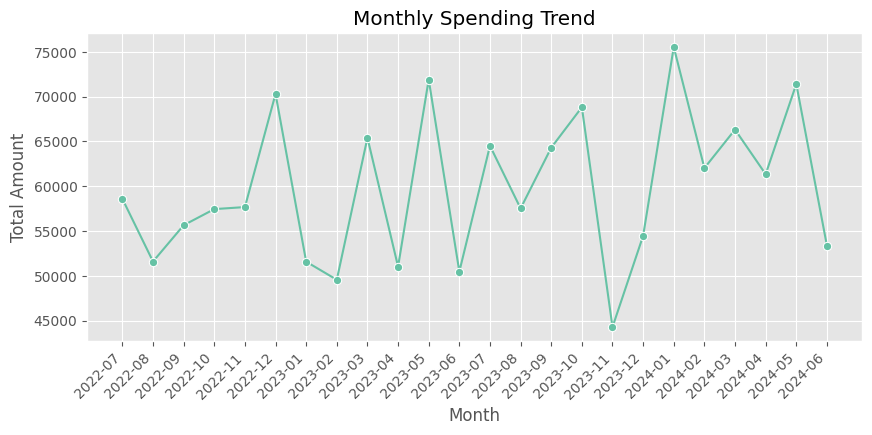

In [34]:
plt.figure(figsize=(10,4))
sns.lineplot(data=month_sum, x="Month", y="Amount", marker="o")
plt.title("Monthly Spending Trend")
plt.xlabel("Month"); plt.ylabel("Total Amount")
plt.xticks(rotation=45, ha='right')
plt.show()

### Transactions

Transaction amounts are right-skewed: most purchases are small, while a few high-value transactions heavily influence totals.

Home & Garden and Electronics categories dominate overall spending, highlighting lifestyle and tech as key drivers of revenue.

Spending trends show fluctuations across months, which may reflect seasonality or marketing campaigns.

# Social Media

In [35]:
# Summary
display(social_v2.describe(include="all"))

,CustomerID,InteractionID,InteractionDate,Platform,InteractionType,Sentiment
count,3020,3020,3020,3020,3020,3020
unique,1893,3000,450,4,3,6
top,a14c5d2f-87d8-4caf-b91e-ab6865872c37,3a30bab5-53a0-4169-8244-419e2459dcd9,2023-07-02,Instagram,Comment,Positive
freq,5,2,16,921,1018,905


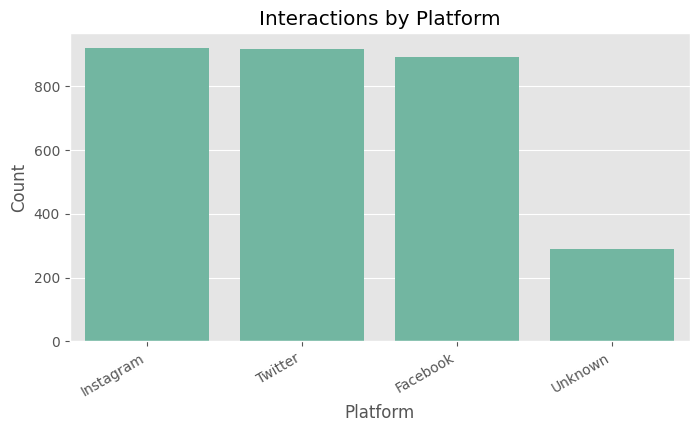

In [36]:
# Platform usage
plt.figure(figsize=(8,4))
order_plat = social_v2["Platform"].value_counts().index
sns.countplot(data=social_v2, x="Platform", order=order_plat)
plt.title("Interactions by Platform")
plt.xlabel("Platform"); plt.ylabel("Count")
plt.xticks(rotation=30, ha='right')
plt.show()

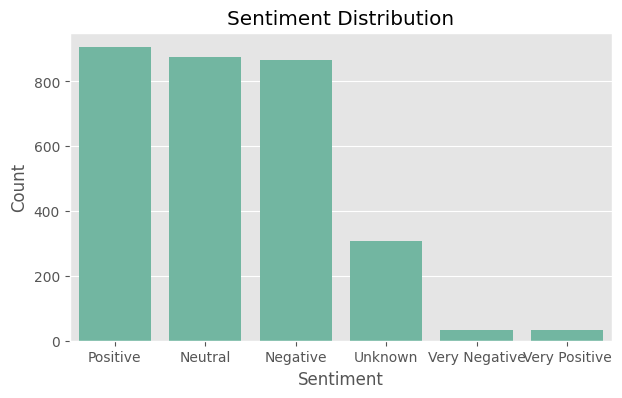

In [37]:
# Sentiment distribution
plt.figure(figsize=(7,4))
order_sent = social_v2["Sentiment"].value_counts().index
sns.countplot(data=social_v2, x="Sentiment", order=order_sent)
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment"); plt.ylabel("Count")
plt.show()

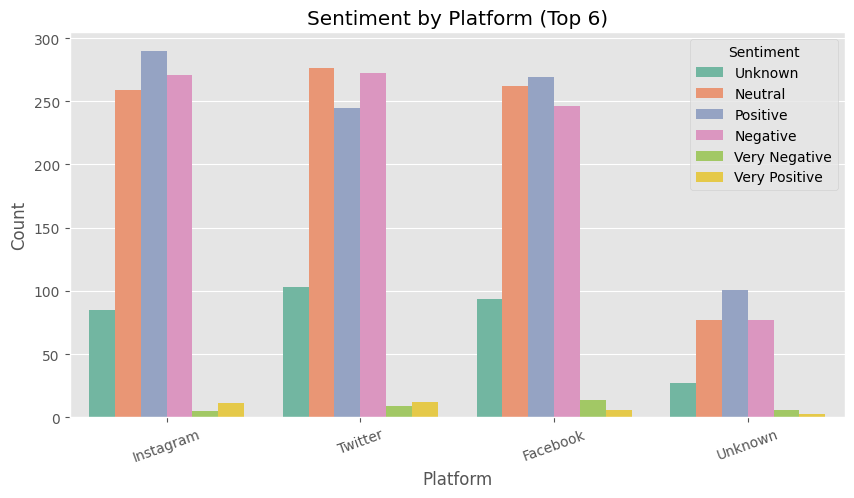

In [38]:
# Sentiment by top platforms
top_plats = social_v2["Platform"].value_counts().head(6).index
tmp = social_v2[social_v2["Platform"].isin(top_plats)]
plt.figure(figsize=(10,5))
sns.countplot(data=tmp, x="Platform", hue="Sentiment", order=top_plats)
plt.title("Sentiment by Platform (Top 6)")
plt.xlabel("Platform"); plt.ylabel("Count")
plt.xticks(rotation=20)
plt.legend(title="Sentiment")
plt.show()

In [39]:
# Interaction trends over time
social_v2["InteractionDate"] = pd.to_datetime(social_v2["InteractionDate"], errors="coerce")
s_ts = social_v2.dropna(subset=["InteractionDate"]).copy()
s_ts["Month"] = s_ts["InteractionDate"].dt.to_period("M").astype(str)
interactions_per_month = s_ts.groupby("Month")["InteractionID"].count().reset_index(name="Interactions")

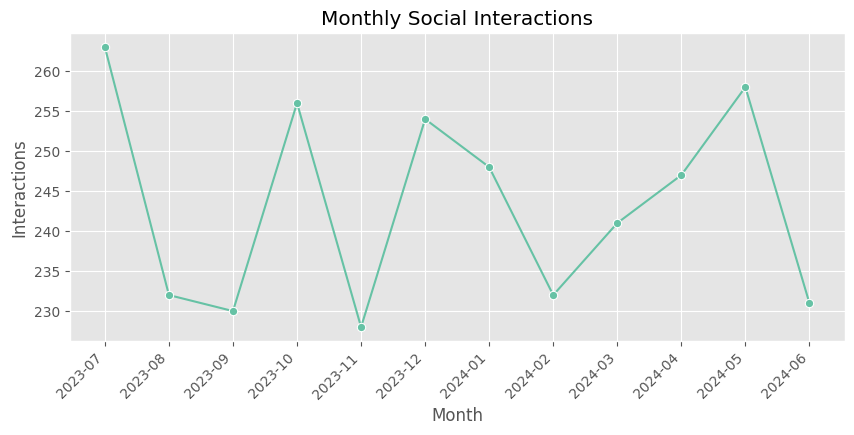

In [40]:
plt.figure(figsize=(10,4))
sns.lineplot(data=interactions_per_month, x="Month", y="Interactions", marker="o")
plt.title("Monthly Social Interactions")
plt.xlabel("Month"); plt.ylabel("Interactions")
plt.xticks(rotation=45, ha='right')
plt.show()

### Social Media Interactions

Engagement varies strongly by platform, with certain platforms drawing the majority of interactions.

Sentiment is mixed, though neutral and positive tones dominate, indicating generally healthy customer engagement.

Interaction volumes trend upward over time, showing growing online activity around FinMark.

## Cross-EDA

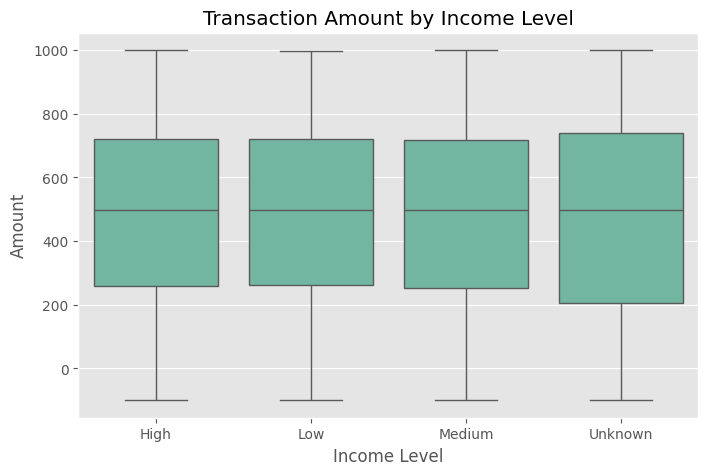

In [41]:
# Merge Transactions + Demographics
merged = pd.merge(transactions_v2, demographics_v2, on="CustomerID", how="inner")

# Spending by Income Level
plt.figure(figsize=(8,5))
sns.boxplot(data=merged, x="IncomeLevel", y="Amount", order=order_inc)
plt.title("Transaction Amount by Income Level")
plt.xlabel("Income Level"); plt.ylabel("Amount")
plt.show()

In [42]:
# Spending by Age Group
merged["AgeGroup"] = pd.cut(merged["Age"], bins=[18,30,45,60,80],
                            labels=["18-30","31-45","46-60","61-80"], include_lowest=True)
age_med = merged.groupby("AgeGroup")["Amount"].median()

/tmp/ipython-input-2824397537.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_med = merged.groupby("AgeGroup")["Amount"].median()


/tmp/ipython-input-3912989739.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=age_med.index, y=age_med.values, ci=None)


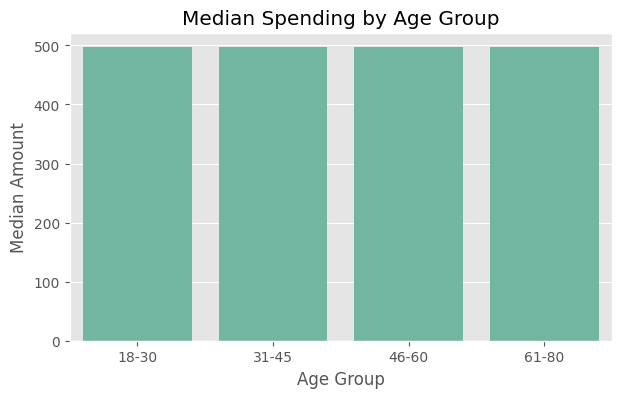

In [43]:
plt.figure(figsize=(7,4))
sns.barplot(x=age_med.index, y=age_med.values, ci=None)
plt.title("Median Spending by Age Group")
plt.xlabel("Age Group"); plt.ylabel("Median Amount")
plt.show()

In [44]:
# Top Product Category per Income Level
pivot_inc_cat = merged.pivot_table(index="IncomeLevel", columns="ProductCategory",
                                   values="Amount", aggfunc="sum", fill_value=0)
display(pivot_inc_cat)

top_cat = pivot_inc_cat.idxmax(axis=1)
top_val = pivot_inc_cat.max(axis=1)
display(pd.DataFrame({"TopCategory": top_cat, "TotalSpend": top_val}).sort_index())


ProductCategory,Automotive,Clothing,Electronics,Health & Beauty,Home & Garden,Unknown
IncomeLevel,,,,,,
High,81521.940,90996.215,82636.050,76633.520,95253.930,40768.990
Low,83463.075,86951.000,91092.235,82957.585,69829.880,33925.775
Medium,76036.505,79105.000,78686.910,73245.610,79574.790,46239.475
Unknown,25843.995,24367.250,22218.380,17440.120,25970.775,14094.280


,TopCategory,TotalSpend
IncomeLevel,,
High,Home & Garden,95253.930
Low,Electronics,91092.235
Medium,Home & Garden,79574.790
Unknown,Home & Garden,25970.775


### Cross-Dataset Insights

High-income customers contribute most to spending, especially in Home & Garden products.

Younger groups (18–30) spend less on average, while middle-aged groups (31–60) are the biggest contributors.

Linking sentiment with spending suggests potential to segment customers by both engagement style and purchase behavior.